In [2]:
import sys
sys.path.append('../')
import scipy.io as sio
import mat73
import pandas as pd
import torch
import numpy as np
import torch.optim as optim
import torch.nn
import sklearn
import sklearn.metrics
import matplotlib.pyplot as plt
from alive_progress import alive_bar
from  utils.my_classes import dataset 
from torch.utils.data import DataLoader
import utils.DNN_functions as DNN_functions
import scipy
import random
import utils.AMSloss
seed = 16  # You can choose any integer value as the seed
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
# Set seed for Python's random module
random.seed(seed)
# Set seed for NumPy
np.random.seed(seed)
# Set seed for PyTorch (CPU and GPU, if available)
if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
# Set deterministic flags for PyTorch (if available)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

c:\Users\avish\OneDrive\Desktop\thesis_research\avishai_work\env\lib\site-packages\scipy\__init__.py:177: UserWarning: A NumPy version >=1.18.5 and <1.26.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [3]:
#To get my GPU device - GTX 4070 :)
seed = 16  # You can choose any integer value as the seed
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu');

if torch.cuda.is_available():
    print(torch.cuda.device_count())
    print(torch.cuda.device(0))
    print(torch.cuda.get_device_name(0))
    print(device)

1
NVIDIA GeForce RTX 4070
cuda


In [4]:
from ASV_utils.data_loading import *



models_folder = "ECAPA_TDNN/inference_models/"

data_path_male = "Data/pmf_both/not_normalize/male/"

data_path_female = "Data/pmf_both/not_normalize/female/"

embedded_groups_1_1_male,embedded_groups_1_2_male,embedded_groups_1_3_male,chosen_labels_1_1_is_spoofed_male,chosen_labels_2_1_is_spoofed_male,chosen_labels_3_1_is_spoofed_male,chosen_labels_numeric_1_1_male,chosen_labels_numeric_2_1_male,chosen_labels_numeric_3_1_male,chosen_labels_1_1_attack_logical_male,chosen_labels_2_1_attack_logical_male,chosen_labels_3_1_attack_logical_male,chosen_labels_1_1_name_male,chosen_labels_2_1_name_male,chosen_labels_3_1_name_male,chosen_labels_1_1_speaker_id_male,chosen_labels_2_1_speaker_id_male,chosen_labels_3_1_speaker_id_male,male_chosen_labels_1_1_sex_male,male_chosen_labels_2_1_sex_male,male_chosen_labels_3_1_sex_male  = load_data_male(data_path_male)

embedded_groups_1_1_female,embedded_groups_1_2_female,embedded_groups_1_3_female,chosen_labels_1_1_is_spoofed_female,chosen_labels_2_1_is_spoofed_female,chosen_labels_3_1_is_spoofed_female,chosen_labels_numeric_1_1_female,chosen_labels_numeric_2_1_female,chosen_labels_numeric_3_1_female,chosen_labels_1_1_attack_logical_female,chosen_labels_2_1_attack_logical_female,chosen_labels_3_1_attack_logical_female,chosen_labels_1_1_name_female,chosen_labels_2_1_name_female,chosen_labels_3_1_name_female,chosen_labels_1_1_speaker_id_female,chosen_labels_2_1_speaker_id_female,chosen_labels_3_1_speaker_id_female,female_chosen_labels_1_1_sex_female,female_chosen_labels_2_1_sex_female,female_chosen_labels_3_1_sex_female   = load_data_female(data_path_female)

In [5]:
## load Embedded Groups
# Group 1 - Train Set
# Group 2 - Dev Set - validation set
# Grup 3 - Eval Set - test set
embedded_groups_1_1 = np.vstack((embedded_groups_1_1_male,embedded_groups_1_1_female));
embedded_groups_1_2 = np.vstack((embedded_groups_1_2_male,embedded_groups_1_2_female));
embedded_groups_1_3 = np.vstack((embedded_groups_1_3_male,embedded_groups_1_3_female));

chosen_labels_1_1_is_spoofed = pd.concat([chosen_labels_1_1_is_spoofed_male,chosen_labels_1_1_is_spoofed_female]);
chosen_labels_2_1_is_spoofed = pd.concat([chosen_labels_2_1_is_spoofed_male,chosen_labels_2_1_is_spoofed_female]);
chosen_labels_3_1_is_spoofed = pd.concat([chosen_labels_3_1_is_spoofed_male,chosen_labels_3_1_is_spoofed_female]);
chosen_labels_1_1_is_spoofed.reset_index(drop=True,inplace=True)
chosen_labels_2_1_is_spoofed.reset_index(drop=True,inplace=True)
chosen_labels_3_1_is_spoofed.reset_index(drop=True,inplace=True)
 
chosen_labels_numeric_1_1 = pd.concat([chosen_labels_numeric_1_1_male,chosen_labels_numeric_1_1_female]);
chosen_labels_numeric_2_1 = pd.concat([chosen_labels_numeric_2_1_male,chosen_labels_numeric_2_1_female]);
chosen_labels_numeric_3_1 = pd.concat([chosen_labels_numeric_3_1_male,chosen_labels_numeric_3_1_female]);
chosen_labels_numeric_1_1.reset_index(drop=True,inplace=True)
chosen_labels_numeric_2_1.reset_index(drop=True,inplace=True)
chosen_labels_numeric_3_1.reset_index(drop=True,inplace=True)

chosen_labels_1_1_attack_logical = pd.concat([chosen_labels_1_1_attack_logical_male,chosen_labels_1_1_attack_logical_female]);
chosen_labels_2_1_attack_logical = pd.concat([chosen_labels_2_1_attack_logical_male,chosen_labels_2_1_attack_logical_female]);
chosen_labels_3_1_attack_logical = pd.concat([chosen_labels_3_1_attack_logical_male,chosen_labels_3_1_attack_logical_female]);
chosen_labels_1_1_attack_logical.reset_index(drop=True,inplace=True)
chosen_labels_2_1_attack_logical.reset_index(drop=True,inplace=True)
chosen_labels_3_1_attack_logical.reset_index(drop=True,inplace=True)

chosen_labels_1_1_name = pd.concat([chosen_labels_1_1_name_male,chosen_labels_1_1_name_female]);
chosen_labels_2_1_name = pd.concat([chosen_labels_2_1_name_male,chosen_labels_2_1_name_female]);
chosen_labels_3_1_name = pd.concat([chosen_labels_3_1_name_male,chosen_labels_3_1_name_female]);
chosen_labels_1_1_name.reset_index(drop=True,inplace=True)
chosen_labels_2_1_name.reset_index(drop=True,inplace=True)
chosen_labels_3_1_name.reset_index(drop=True,inplace=True)

chosen_labels_1_1_speaker_id = pd.concat([chosen_labels_1_1_speaker_id_male,chosen_labels_1_1_speaker_id_female]);
chosen_labels_2_1_speaker_id = pd.concat([chosen_labels_2_1_speaker_id_male,chosen_labels_2_1_speaker_id_female]);
chosen_labels_3_1_speaker_id = pd.concat([chosen_labels_3_1_speaker_id_male,chosen_labels_3_1_speaker_id_female]);
chosen_labels_1_1_speaker_id.reset_index(drop=True,inplace=True)
chosen_labels_2_1_speaker_id.reset_index(drop=True,inplace=True)
chosen_labels_3_1_speaker_id.reset_index(drop=True,inplace=True)

chosen_labels_1_1_sex = pd.concat([male_chosen_labels_1_1_sex_male,female_chosen_labels_1_1_sex_female]);
chosen_labels_2_1_sex = pd.concat([male_chosen_labels_2_1_sex_male,female_chosen_labels_2_1_sex_female]);
chosen_labels_3_1_sex = pd.concat([male_chosen_labels_3_1_sex_male,female_chosen_labels_3_1_sex_female]);
chosen_labels_1_1_sex.reset_index(drop=True,inplace=True)
chosen_labels_2_1_sex.reset_index(drop=True,inplace=True)
chosen_labels_3_1_sex.reset_index(drop=True,inplace=True)

In [6]:
#order by this example:
#filter-gammatone-channel-1-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]',
#       'filter-gammatone-channel-1-distance-Correlation-[d_(p,p_s)-d(p,p_h)]',
#       'filter-gammatone-channel-1-distance-Hellinger-[d_(p,p_s)-d(p,p_h)]',
#       'filter-gammatone-channel-1-distance-Intersection-[d_(p,p_s)-d(p,p_h)]',
#       'filter-gammatone-channel-1-distance-Jensen-Shannon-[d_(p,p_s)-d(p,p_h)

# get the real channel by the order of the features

import utils.my_functions as my_functions
columns_names,max_name_length = my_functions.get_columns_names_feature_importance(substruct=True)
true_channels_indexes = np.array(my_functions.get_real_channel(np.linspace(start=1, stop=len(columns_names), num=len(columns_names)),len(columns_names)))
true_channels_indexes = true_channels_indexes - 1
true_channels_indexes = true_channels_indexes.astype(int)
columns_names = np.array(columns_names)
embedded_groups_1_1 = embedded_groups_1_1[:,true_channels_indexes]
embedded_groups_1_2 = embedded_groups_1_2[:,true_channels_indexes]
embedded_groups_1_3 = embedded_groups_1_3[:,true_channels_indexes]



In [7]:
# order by metric type and then by channel number and then by gammatone and gammatone_inv, example:
#filter-gammatone-channel-1-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]
#filter-gammatone-channel-2-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]
#filter-gammatone-channel-3-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]
#filter-gammatone-channel-4-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]
#filter-gammatone-channel-5-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]
#filter-gammatone-channel-6-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]
#filter-gammatone-channel-7-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]
#filter-gammatone-channel-8-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]
#filter-gammatone-channel-9-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]
#filter-gammatone-channel-10-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]
#filter-gammatone-channel-1-distance-Correlation-[d_(p,p_s)-d(p,p_h)]
#filter-gammatone-channel-2-distance-Correlation-[d_(p,p_s)-d(p,p_h)]
import re


your_list = columns_names[true_channels_indexes]
index_mapping ={}

# Define the custom sorting order for distance metrics
distance_metrics = [
    'Chi-square',
    'Correlation',
    'Hellinger',
    'Intersection',
    'Jensen-Shannon',
    'Kullback-Leibler Divergence',
    'Modified Kolmogorov-Smirnov',
    'Symmetrised Kullback-Leibler'
]

def custom_sort_key(item):
    # Use regex to extract filter type, channel number, and distance metric
    match = re.search(r'filter-(gammatone|gammtone_inv)-channel-(\d+)-distance-(.+?)-\[d_', item)
    if match:
        filter_type = match.group(1)  # 'gammatone' or 'gammtone_inv'
        channel = int(match.group(2))
        distance_metric = match.group(3)
        
        # Prioritize 'gammatone' before 'gammtone_inv'
        filter_priority = 0 if filter_type == 'gammatone' else 1

        # Sort by filter type, then by distance metric, and finally by channel
        return (filter_priority, distance_metrics.index(distance_metric), channel)

    else:
        # If the regex doesn't match, push the item to the end
        return (999, 999, 999)

# Sort the list based on the custom order
sorted_list = sorted(your_list, key=custom_sort_key)

for new_index, item in enumerate(sorted_list):
    old_index = np.where(columns_names[true_channels_indexes] == item)[0][0]
    index_mapping[old_index] = new_index
    
embedded_groups_1_1 = embedded_groups_1_1[:,list(index_mapping.keys())]
embedded_groups_1_2 = embedded_groups_1_2[:,list(index_mapping.keys())]
embedded_groups_1_3 = embedded_groups_1_3[:,list(index_mapping.keys())]

In [8]:
train_dataset = dataset(data = embedded_groups_1_1 , is_spoofed = chosen_labels_1_1_is_spoofed , chosen_labels_numeric = chosen_labels_numeric_1_1,
                        attack_logical = chosen_labels_1_1_attack_logical, name = chosen_labels_1_1_name , speaker_id = chosen_labels_1_1_speaker_id,sex = chosen_labels_1_1_sex, data_transform = None , labels_transform = None);

validation_dataset = dataset(data = embedded_groups_1_2 , is_spoofed = chosen_labels_2_1_is_spoofed , chosen_labels_numeric = chosen_labels_numeric_2_1,
                        attack_logical = chosen_labels_2_1_attack_logical, name = chosen_labels_2_1_name , speaker_id = chosen_labels_2_1_speaker_id, sex = chosen_labels_2_1_sex ,data_transform = None , labels_transform = None);


test_dataset = dataset(data = embedded_groups_1_3 , is_spoofed = chosen_labels_3_1_is_spoofed , chosen_labels_numeric = chosen_labels_numeric_3_1,
                        attack_logical = chosen_labels_3_1_attack_logical, name = chosen_labels_3_1_name , speaker_id = chosen_labels_3_1_speaker_id, sex = chosen_labels_3_1_sex ,data_transform = None , labels_transform = None);

In [9]:
# normalize the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler(with_mean = True, with_std = True)
scaler.fit(train_dataset.data)
mean_features = scaler.mean_
std_features = scaler.scale_
train_dataset.data = scaler.transform(train_dataset.data)
validation_dataset.data = scaler.transform(validation_dataset.data)
test_dataset.data = scaler.transform(test_dataset.data)

In [10]:
import imblearn.over_sampling as over_sampling
#sm = over_sampling.ADASYN(sampling_strategy='minority', random_state=seed,n_neighbors=5)
sm = over_sampling.SVMSMOTE(sampling_strategy='minority', random_state=seed,k_neighbors=5)
train_dataset.data, train_dataset.is_spoofed = sm.fit_resample(X = train_dataset.data, y = train_dataset.is_spoofed) # just on the train set

In [11]:
print(f"|| train dataset length - {len(train_dataset)} ||");
print(f"|| train dataset - len_is_spoofed ? \nlength - \n{train_dataset.len_is_spoofed()} ||");
print(f"|| validation dataset length - {len(validation_dataset)} ||");
print(f"|| validation dataset - len_is_spoofed ? \nlength - \n{validation_dataset.len_is_spoofed()} ||");
print(f"|| test dataset length - {len(test_dataset)} ||");
print(f"|| test dataset - len_is_spoofed ? \nlength - \n{test_dataset.len_is_spoofed()} ||");

|| train dataset length - 45600 ||
|| train dataset - len_is_spoofed ? 
length - 
0    22800
1    22800
Name: count, dtype: int64 ||
|| validation dataset length - 24844 ||
|| validation dataset - len_is_spoofed ? 
length - 
1    22296
0     2548
Name: count, dtype: int64 ||
|| test dataset length - 71237 ||
|| test dataset - len_is_spoofed ? 
length - 
1    63882
0     7355
Name: count, dtype: int64 ||


In [12]:
train_dataset.set_labels_format('is_spoofed')
validation_dataset.set_labels_format('is_spoofed')
test_dataset.set_labels_format('is_spoofed')

In [13]:
train_dataloader = DataLoader(train_dataset, batch_size=128, shuffle=True);
validation_dataloader = DataLoader(validation_dataset, batch_size=128, shuffle=True);
test_dataloader = DataLoader(test_dataset, batch_size=128, shuffle=True);

print(f"|| train dataloader length - {len(train_dataloader)} ||");
print(f"|| validation dataloader length - {len(validation_dataloader)} ||");
print(f"|| test dataloader length - {len(test_dataloader)} ||");

|| train dataloader length - 357 ||
|| validation dataloader length - 195 ||
|| test dataloader length - 557 ||


## DNN

In [14]:
import torch.nn as nn
class SubChannelNetwork(nn.Module):
    def __init__(self, input_channel_size, output_channel_size):
        super(SubChannelNetwork, self).__init__()
        self.input_layer = nn.Linear(input_channel_size, output_channel_size)
        self.sigmoid = nn.Sigmoid()
        self.dropout = nn.Dropout(p=0.2)
        self.BN_4 = nn.BatchNorm1d(output_channel_size) 
   
    def forward(self, x):
        res = x
        x = self.input_layer(x)
        x = self.BN_4(x) 
        x = self.sigmoid(x)
        x = self.dropout(x)
        x = res + x 
        return x

In [15]:
import torch
import torch.nn as nn
from utils.AMSloss import AdMSoftmaxLoss
from utils.OCSoftmaxloss import OCSoftmax


class DNN(nn.Module):
    def __init__(self, input_channel_size, num_subnetworks, output_channel_size, final_output_size, r_real , r_fake,alpha):
        super(DNN, self).__init__()
        self.SubChannelNetwork = nn.ModuleList([
            SubChannelNetwork(input_channel_size, output_channel_size) for _ in range(num_subnetworks)
        ])
        self.fc_between_subnet = nn.Linear(num_subnetworks * output_channel_size,80)
        self.BN = nn.BatchNorm1d(80)
        self.fc = nn.Linear(80, final_output_size)
        self.sigmoid = nn.Sigmoid()
        self.droupout = nn.Dropout(p=0.2)
        self.r_real = r_real
        self.r_fake = r_fake
        self.alpha = alpha
        self.loss = OCSoftmax(feat_dim = final_output_size, r_real = self.r_real, r_fake = self.r_fake, alpha = self.alpha)
        self.optimizer = None
        self.scheduler = None
        
        
    def forward(self, x):
        subnetwork_outputs = [self.SubChannelNetwork[idx](x[:, idx*input_channel_size:(idx+1)*input_channel_size].to(device)) for idx in range(len(self.SubChannelNetwork))]
        combined_output = torch.cat(subnetwork_outputs, dim=1)
        x = self.fc_between_subnet(combined_output)    
        x = self.BN(x)
        x = self.sigmoid(x)
        x = self.droupout(x)
        output = self.fc(x)
        return output 
    
    @staticmethod
    def count_parameters(model):
        return sum(p.numel() for p in model.parameters() if p.requires_grad)


r_real = 0.9 
r_fake = 0.5
alpha = 20
# Example usage
num_SubChannelNetwork = 16
input_channel_size = 10
output_channel_size = 10
final_output_size = 16*3
model = []
model = DNN(input_channel_size, num_SubChannelNetwork, output_channel_size, final_output_size,r_real = r_real , r_fake =r_fake,alpha = 20)
model = model.to(device)
print(model)

n = DNN.count_parameters(model)
print("Number of parameters: %s" % n)
model = []

r_real = 0.9 
r_fake = 0.5
alpha = 5
final_output_size = 16*2
model = DNN(input_channel_size, num_SubChannelNetwork, output_channel_size, final_output_size,r_real = r_real , r_fake = r_fake,alpha = alpha)
model = model.to(device)
num_epoch = 200
learning_rate = 0.001
weight_decay = 0.000001


DNN(
  (SubChannelNetwork): ModuleList(
    (0-15): 16 x SubChannelNetwork(
      (input_layer): Linear(in_features=10, out_features=10, bias=True)
      (sigmoid): Sigmoid()
      (dropout): Dropout(p=0.2, inplace=False)
      (BN_4): BatchNorm1d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (fc_between_subnet): Linear(in_features=160, out_features=80, bias=True)
  (BN): BatchNorm1d(80, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc): Linear(in_features=80, out_features=48, bias=True)
  (sigmoid): Sigmoid()
  (droupout): Dropout(p=0.2, inplace=False)
  (loss): OCSoftmax(
    (softplus): Softplus(beta=1, threshold=20)
  )
)
Number of parameters: 19056


In [16]:
import utils.DNN_functions

model.optimizer = torch.optim.SGD(model.parameters(),
                                lr=learning_rate,
                                weight_decay=weight_decay);


model.scheduler =  optim.lr_scheduler.StepLR(model.optimizer, step_size=num_epoch, gamma=0.1);

checkpoint_path =  'male_and_female_2_neorun_end_OCS_both.pkl'

training_type = '2_neorun_end_OCS'

model,train_losses,validation_losses,train_acc_percentage,validation_acc_percentage,f1_score_validation,validation_total_eer,train_total_err  = utils.DNN_functions.train_model_new(training_type,model,train_dataloader,validation_dataloader ,num_epoch,checkpoint_path=checkpoint_path,patience = None)


c:\Users\avish\OneDrive\Desktop\thesis_research\avishai_work\env\lib\site-packages\torch\onnx\_internal\_beartype.py:35: UserWarning: unhashable type: 'list'
  warnings.warn(f"{e}")


on 1: 
      Train Balanced Accuracy:  68.76%
on 1: Train EER:  31.24%
on 1: 
      Validation 1 ,Validation Loss 0.96420 , Validation Balanced Accuracy: 87.46%
on 1: Validation EER:  12.56%
on 1: Validation f1 Score: 87.45%
on 1: 
on 1: 
on 2: 
      Train Balanced Accuracy:  86.90%
on 2: Train EER:  13.10%
on 2: 
      Validation 2 ,Validation Loss 0.42913 , Validation Balanced Accuracy: 97.38%
on 2: Validation EER:  2.63%
on 2: Validation f1 Score: 97.38%
on 2: 
on 2: 
on 3: 
      Train Balanced Accuracy:  94.78%
on 3: Train EER:  5.22%
on 3: 
      Validation 3 ,Validation Loss 0.29559 , Validation Balanced Accuracy: 98.95%
on 3: Validation EER:  1.06%
on 3: Validation f1 Score: 98.93%
on 3: 
on 3: 
on 4: 
      Train Balanced Accuracy:  96.60%
on 4: Train EER:  3.40%
on 4: 
      Validation 4 ,Validation Loss 0.23679 , Validation Balanced Accuracy: 99.33%
on 4: Validation EER:  0.67%
on 4: Validation f1 Score: 99.34%
on 4: 
on 4: 
on 5: 
      Train Balanced Accuracy:  97.58%
on 

In [17]:
import pickle 
#file_path = checkpoint_path

# Open the file in binary write mode
#with open(file_path, 'wb') as f:
    # Serialize the object and write it to the file
#    pickle.dump(model, f)


c:\Users\avish\OneDrive\Desktop\thesis_research\avishai_work\utils\DNN_functions.py:141: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


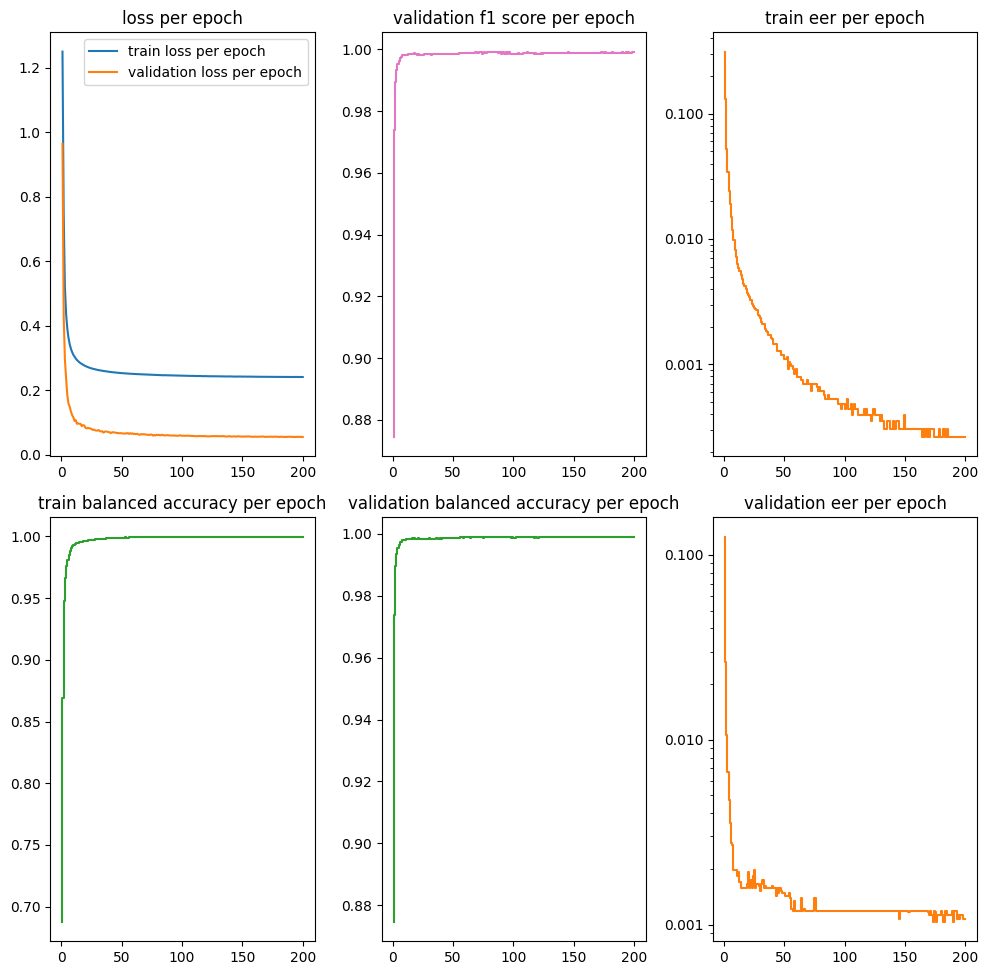

In [18]:
import matplotlib.pyplot as plt
DNN_functions.plot_loss_accuracy(num_epoch,train_losses,validation_losses,train_acc_percentage,validation_acc_percentage,f1_score_validation,validation_total_eer,train_total_err)

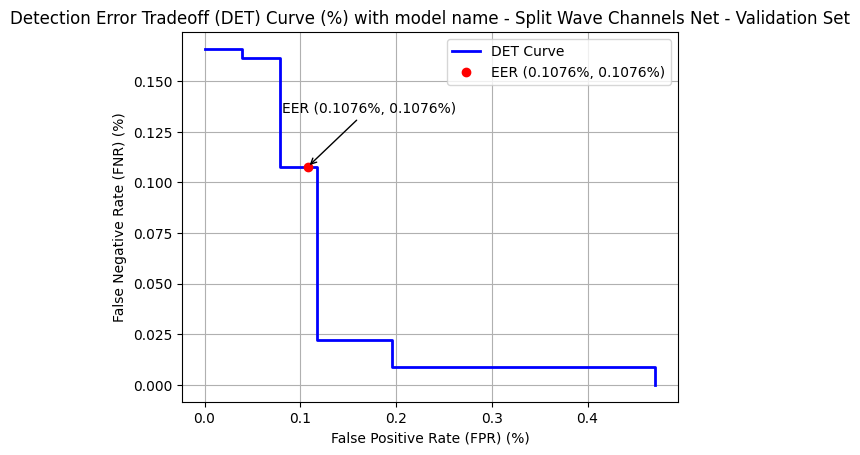

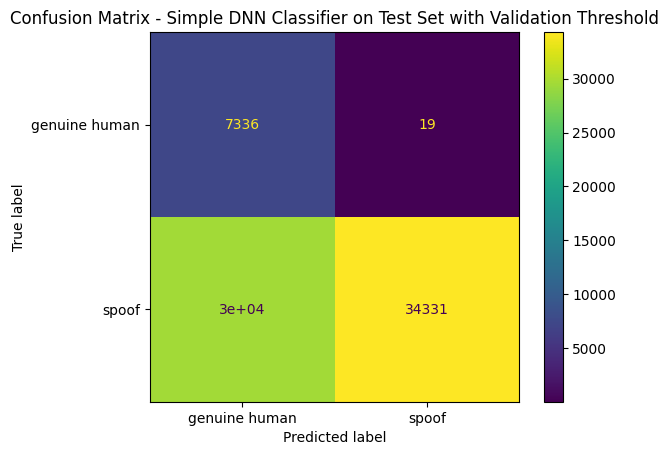

	Test Balanced Accuracy: (0.76741%) 	F1 Score: 0.58491
	Test EER: 0.001076426264737441 	Threshold: -0.8789823616010454


In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import det_curve
import torch.nn.functional as F 

with torch.no_grad():
    model = model.to(device)
    validation_output = model(torch.Tensor(validation_dataset.data).to(device)).cpu()
    loss , validation_score = model.loss(torch.Tensor(validation_output).to(device),torch.LongTensor(validation_dataset.is_spoofed).to(device))
    validation_score = -1*validation_score
    validation_norm_output = F.normalize(validation_output)
    
validation_score_total = validation_score.cpu().numpy().copy()

validation_total_labels = validation_dataset.is_spoofed.copy()

eer, val_thresh = my_functions.compute_eer(validation_total_labels,validation_score_total) # compute equal error rate

fpr, fnr, _ = det_curve(validation_total_labels, validation_score_total) # compute false positive rate and false negative rate

my_functions.DETCurve(fpr = fpr, fnr = fnr, eer_fpr = eer,eer_fnr = eer, model_name = "Split Wave Channels Net - Validation Set",plot_type="step") # plot DET curve

with torch.no_grad():
    model = model.to(device)
    test_output = model(torch.Tensor(test_dataset.data).to(device))
    loss , test_score = model.loss(torch.Tensor(test_output).to(device),torch.LongTensor(test_dataset.is_spoofed).to(device))
    test_score = -1*test_score
    test_norm_output = F.normalize(test_output)

test_score_total = test_score.cpu().numpy().copy()

test_total_labels = test_dataset.is_spoofed.copy()

prediction = np.array([1 if total_prob_element > val_thresh else 0 for total_prob_element in test_score_total]) # prediction for specific threshold

valid_thr_prediction_dnn = prediction.copy()

cm = sklearn.metrics.confusion_matrix(test_total_labels, valid_thr_prediction_dnn) # confusion matrix
cm = np.round(cm,2)

# print confusion matrix - logistic regression
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                display_labels=["genuine human","spoof"])
disp.plot()
plt.title('Confusion Matrix - Simple DNN Classifier on Test Set with Validation Threshold')
plt.show()

    
balanced_acc= sklearn.metrics.balanced_accuracy_score(test_total_labels,valid_thr_prediction_dnn) # balanced accuracy per batch

f1_score =sklearn.metrics.f1_score(test_total_labels, valid_thr_prediction_dnn, average='micro') # f1 score  
   
print(f"\tTest Balanced Accuracy: ({balanced_acc:.5f}%) \tF1 Score: {f1_score:.5f}")
print(f"\tTest EER: {eer} \tThreshold: {val_thresh}")

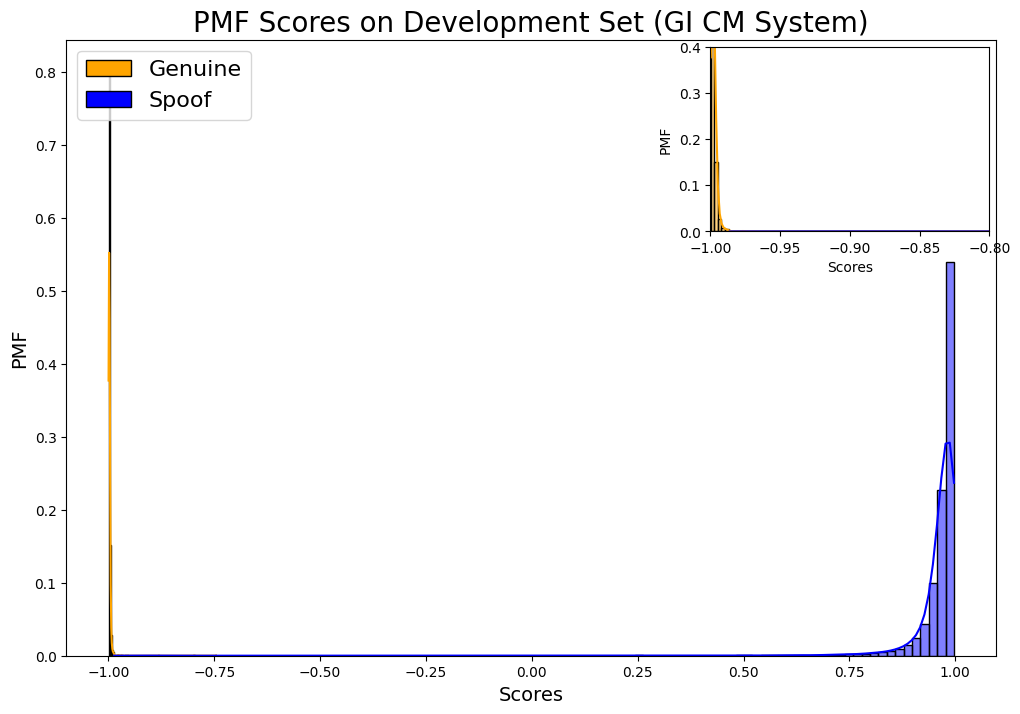

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

bonafide_scores = validation_score[validation_dataset.is_spoofed == 0].flatten()
spoof_scores = validation_score[validation_dataset.is_spoofed == 1].flatten()
bonafide_scores = bonafide_scores.cpu().numpy()
spoof_scores = spoof_scores.cpu().numpy()

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch  # For block-style legend


num_bins = 100

# Plot 1: Separate histograms for Genuine and Spoof
fig, ax = plt.subplots(figsize=(12, 8))

sns.histplot(bonafide_scores, kde=True, stat='probability', bins=num_bins, color='orange', linewidth=1, ax=ax)
sns.histplot(spoof_scores, kde=True, stat='probability', bins=num_bins, color='blue', linewidth=1, ax=ax)

ax.legend(['Genuine', 'Spoof'], fontsize=14)
ax.set_xlabel('Scores', fontsize=14)
ax.set_ylabel('PMF', fontsize=14)
ax.set_title("PMF Scores on Development Set (GI CM System)", fontsize=20)

# Add inset plot
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

inset_ax = inset_axes(ax, width="30%", height="30%", loc='upper right')  # Position inset
zoom_range = (-1, -0.80)  # Adjust zoom range for your data

sns.histplot(bonafide_scores, kde=True, stat='probability', bins=num_bins, color='orange', linewidth=1, ax=inset_ax)
sns.histplot(spoof_scores, kde=True, stat='probability', bins=num_bins, color='blue', linewidth=1, ax=inset_ax)

# Create block-style legend
legend_elements = [
    Patch(facecolor='orange', edgecolor='black', label='Genuine'),
    Patch(facecolor='blue', edgecolor='black', label='Spoof')
]
ax.legend(handles=legend_elements, fontsize=16, loc='upper left')


inset_ax.set_xlim(zoom_range)  # Focus x-axis
inset_ax.set_ylim(0, 0.4)      # Adjust y-axis range if needed
inset_ax.set_xlabel('Scores')        # Optional: remove inset labels for clarity
inset_ax.set_ylabel('PMF')

plt.show()

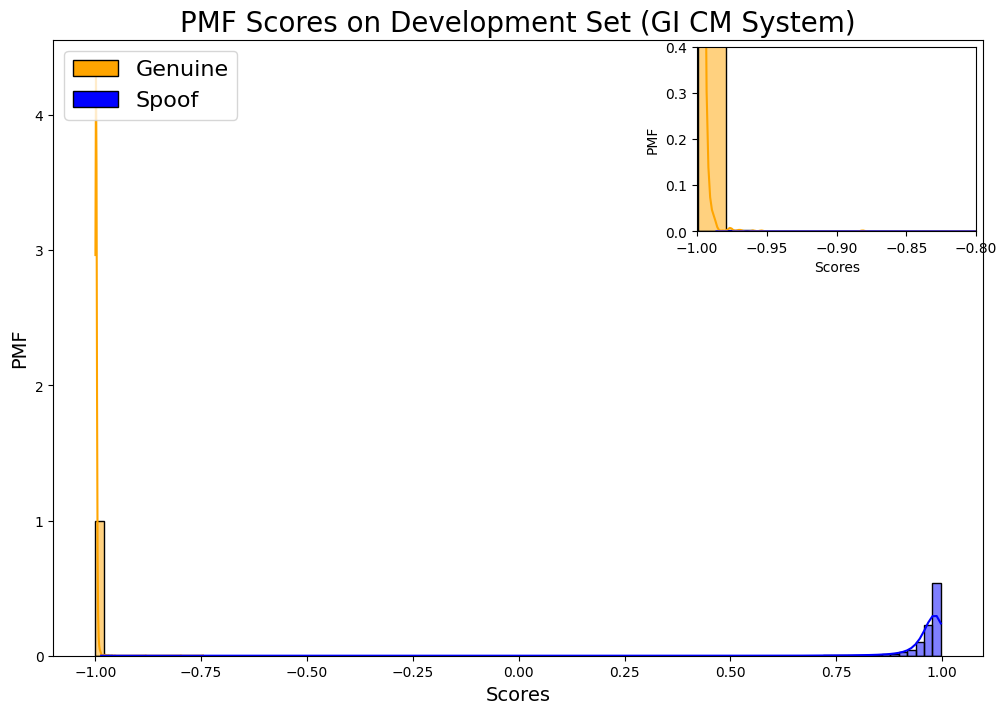

In [21]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch  # For block-style legend
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Convert tensors to numpy
bonafide_scores = validation_score[validation_dataset.is_spoofed == 0].flatten().cpu().numpy()
spoof_scores = validation_score[validation_dataset.is_spoofed == 1].flatten().cpu().numpy()

# Compute shared bin edges for equal-width bins
num_bins = 100
min_score = min(bonafide_scores.min(), spoof_scores.min())  # Minimum across both distributions
max_score = max(bonafide_scores.max(), spoof_scores.max())  # Maximum across both distributions
bin_edges = np.linspace(min_score, max_score, num_bins + 1)  # Equal-width bins

# Main figure
fig, ax = plt.subplots(figsize=(12, 8))

# Main plot with histograms using shared bin edges
sns.histplot(bonafide_scores, kde=True, stat='probability', bins=bin_edges, color='orange', linewidth=1, ax=ax)
sns.histplot(spoof_scores, kde=True, stat='probability', bins=bin_edges, color='blue', linewidth=1, ax=ax)

# Add labels, title, and legend
ax.set_xlabel('Scores', fontsize=14)
ax.set_ylabel('PMF', fontsize=14)
ax.set_title("PMF Scores on Development Set (GI CM System)", fontsize=20)

# Create block-style legend
legend_elements = [
    Patch(facecolor='orange', edgecolor='black', label='Genuine'),
    Patch(facecolor='blue', edgecolor='black', label='Spoof')
]
ax.legend(handles=legend_elements, fontsize=16, loc='upper left')

# Adding an inset plot
inset_ax = inset_axes(ax, width="30%", height="30%", loc='upper right')  # Adjust size and location

# Zoomed-in region, adjust xlim and ylim based on your data
zoom_range = (-1, -0.80)  # Adjust based on your data
sns.histplot(bonafide_scores, kde=True, stat='probability', bins=bin_edges, color='orange', linewidth=1, ax=inset_ax)
sns.histplot(spoof_scores, kde=True, stat='probability', bins=bin_edges, color='blue', linewidth=1, ax=inset_ax)

inset_ax.set_xlim(zoom_range)  # Define zoomed-in x-axis range
inset_ax.set_ylim(0, 0.4)      # Define zoomed-in y-axis range
inset_ax.set_xlabel('Scores')        
inset_ax.set_ylabel('PMF')

plt.show()


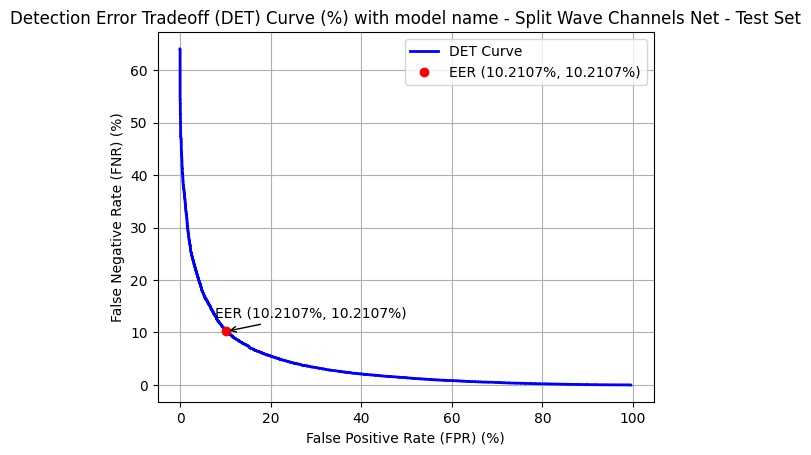

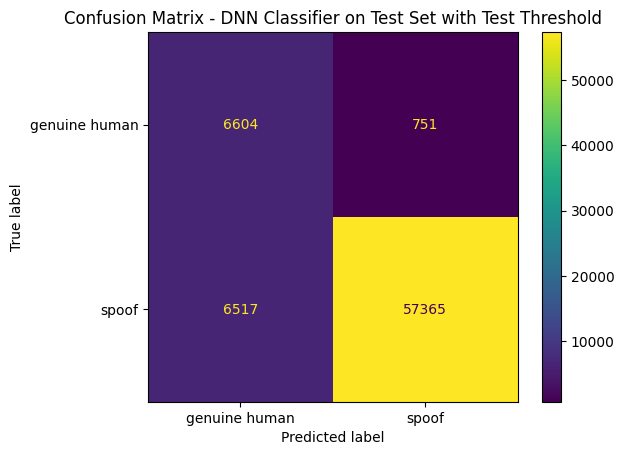

	Test Balanced Accuracy: (0.89794%) 	F1 Score: 0.89797
	Test EER: (0.10210740992543693%) 	Test Threshold: -0.9951076507568362


In [22]:
total_labels = torch.Tensor(test_dataset.is_spoofed.iloc[:]).cpu().numpy().copy()

with torch.no_grad():
    model = model.to(device)
    test_output = model(torch.Tensor(test_dataset.data).to(device))
    loss , test_score = model.loss(torch.Tensor(test_output).to(device),torch.LongTensor(total_labels).to(device))
    test_score = -1*test_score
    test_norm_output = F.normalize(test_output)
    
test_score_total = test_score.cpu().numpy().copy()

eer, test_thresh = my_functions.compute_eer(total_labels,test_score_total) # compute equal error rate

fpr, fnr, _ = det_curve(total_labels, test_score_total) # compute false positive rate and false negative rate

my_functions.DETCurve(fpr = fpr, fnr = fnr, eer_fpr = eer,eer_fnr = eer, model_name = "Split Wave Channels Net - Test Set",plot_type="step") # plot DET curve
    
prediction = np.array([1 if total_prob_element > test_thresh else 0 for total_prob_element in test_score_total]) # prediction for specific threshold

test_thr_prediction_dnn = prediction.copy()

cm = sklearn.metrics.confusion_matrix(total_labels, test_thr_prediction_dnn) # confusion matrix
cm = np.round(cm,2)

# print confusion matrix - logistic regression
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                display_labels=["genuine human","spoof"])
disp.plot()
plt.title('Confusion Matrix - DNN Classifier on Test Set with Test Threshold')
plt.show()

    
balanced_acc= sklearn.metrics.balanced_accuracy_score(total_labels,test_thr_prediction_dnn) # balanced accuracy per batch

f1_score =sklearn.metrics.f1_score(total_labels, test_thr_prediction_dnn, average='micro') # f1 score  
   
print(f"\tTest Balanced Accuracy: ({balanced_acc:.5f}%) \tF1 Score: {f1_score:.5f}")
print(f"\tTest EER: ({eer}%) \tTest Threshold: {test_thresh}")

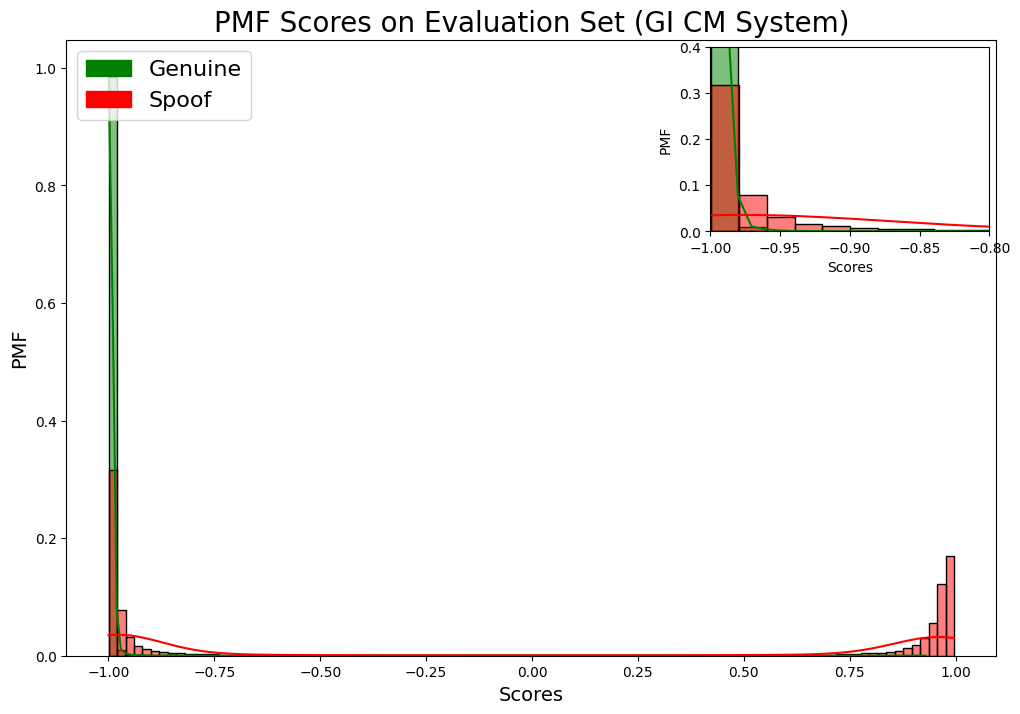

In [23]:
bonafide_scores = test_score[test_dataset.is_spoofed == 0].flatten()
spoof_scores = test_score[test_dataset.is_spoofed == 1].flatten()

bonafide_scores = bonafide_scores.cpu().numpy()
spoof_scores = spoof_scores.cpu().numpy()

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch  # For block-style legend

num_bins = 100
# Colors for the plots
bonafide_color = '#008000'  # Green in hex
spoof_color = '#FF0000'     # Red in hex
# Main figure
fig, ax = plt.subplots(figsize=(12, 8))

# Main plot with histograms
sns.histplot(bonafide_scores, kde=True, stat='probability', bins=num_bins, color=bonafide_color, linewidth=1, ax=ax,legend=True)
sns.histplot(spoof_scores, kde=True, stat='probability', bins=num_bins, color=spoof_color, linewidth=1, ax=ax,legend=True)

# Add labels, title, and legend
ax.set_xlabel('Scores', fontsize=14)
ax.set_ylabel('PMF', fontsize=14)
ax.set_title(f"PMF Scores on Evaluation Set (GI CM System)", fontsize=20)
legend_elements = [
    Patch(color=bonafide_color,  label='Genuine'),
    Patch(color=spoof_color,  label='Spoof')
]
ax.legend(handles=legend_elements, fontsize=16, loc='upper left')
#ax.legend(['Genuine', 'Spoof'], fontsize=14, loc='upper left')

# Adding an inset plot
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Define the inset plot
inset_ax = inset_axes(ax, width="30%", height="30%", loc='upper right')  # Adjust size and location

# Zoomed-in region, adjust xlim and ylim based on your data
zoom_range = (-1, -0.8)  # Adjust based on your data
sns.histplot(bonafide_scores, kde=True, stat='probability', bins=num_bins, color=bonafide_color, linewidth=1, ax=inset_ax)
sns.histplot(spoof_scores, kde=True, stat='probability', bins=num_bins, color=spoof_color, linewidth=1, ax=inset_ax)
inset_ax.set_xlim(zoom_range)  # Define zoomed-in x-axis range
inset_ax.set_ylim(0, 0.4)      # Define zoomed-in y-axis range
inset_ax.set_xlabel('Scores')        # Optional: remove inset labels for clarity
inset_ax.set_ylabel('PMF')

plt.show()


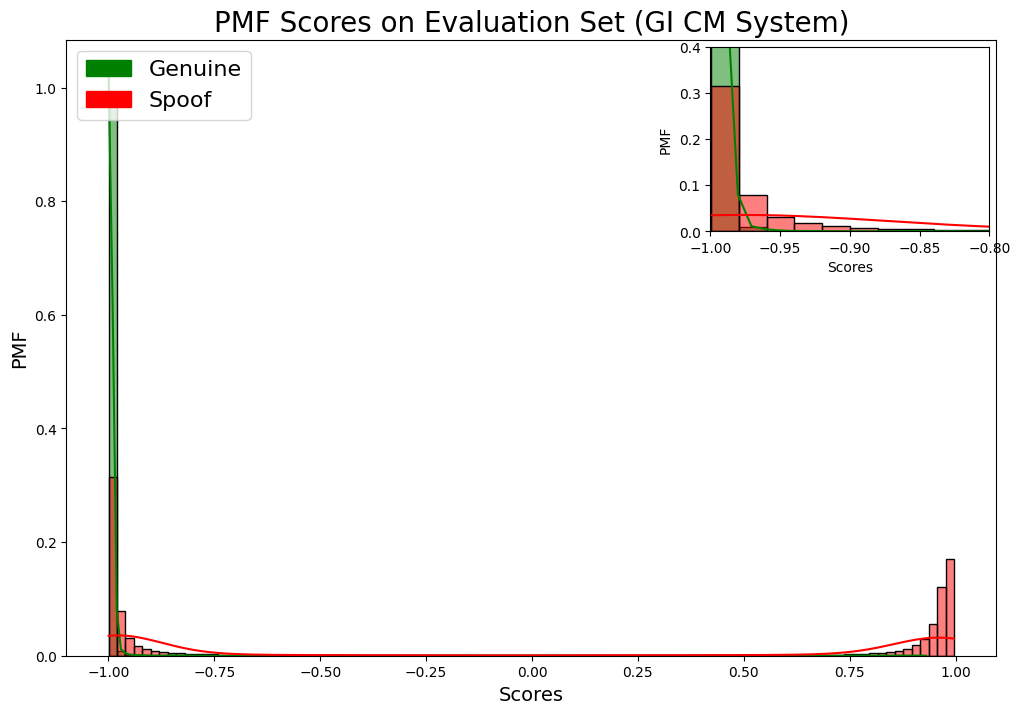

In [24]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch  # For block-style legend
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Convert tensors to numpy
bonafide_scores = test_score[test_dataset.is_spoofed == 0].flatten().cpu().numpy()
spoof_scores = test_score[test_dataset.is_spoofed == 1].flatten().cpu().numpy()

# Compute shared bin edges for equal-width bins
num_bins = 100
min_score = min(bonafide_scores.min(), spoof_scores.min())  # Minimum across both distributions
max_score = max(bonafide_scores.max(), spoof_scores.max())  # Maximum across both distributions
bin_edges = np.linspace(min_score, max_score, num_bins + 1)  # Equal-width bins

# Colors for the plots
bonafide_color = '#008000'  # Green in hex
spoof_color = '#FF0000'     # Red in hex

# Main figure
fig, ax = plt.subplots(figsize=(12, 8))

# Main plot with histograms using shared bin edges
sns.histplot(bonafide_scores, kde=True, stat='probability', bins=bin_edges, color=bonafide_color, linewidth=1, ax=ax)
sns.histplot(spoof_scores, kde=True, stat='probability', bins=bin_edges, color=spoof_color, linewidth=1, ax=ax)

# Add labels, title, and legend
ax.set_xlabel('Scores', fontsize=14)
ax.set_ylabel('PMF', fontsize=14)
ax.set_title("PMF Scores on Evaluation Set (GI CM System)", fontsize=20)

# Create block-style legend
legend_elements = [
    Patch(color=bonafide_color, label='Genuine'),
    Patch(color=spoof_color, label='Spoof')
]
ax.legend(handles=legend_elements, fontsize=16, loc='upper left')

# Adding an inset plot
inset_ax = inset_axes(ax, width="30%", height="30%", loc='upper right')  # Adjust size and location

# Zoomed-in region, adjust xlim and ylim based on your data
zoom_range = (-1, -0.8)  # Adjust based on your data
sns.histplot(bonafide_scores, kde=True, stat='probability', bins=bin_edges, color=bonafide_color, linewidth=1, ax=inset_ax)
sns.histplot(spoof_scores, kde=True, stat='probability', bins=bin_edges, color=spoof_color, linewidth=1, ax=inset_ax)

inset_ax.set_xlim(zoom_range)  # Define zoomed-in x-axis range
inset_ax.set_ylim(0, 0.4)      # Define zoomed-in y-axis range
inset_ax.set_xlabel('Scores')        
inset_ax.set_ylabel('PMF')

plt.show()


In [25]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report,accuracy_score
from sklearn.metrics import balanced_accuracy_score


pred_proba_list = [test_score_total]
y_pred = [test_thr_prediction_dnn]

test_total_labels = [test_dataset.is_spoofed.iloc[:].astype('uint8')]

eer_list = []
acc_list = []
balanced_acc_list = []
auc_list = []
f1_list = [] 
for i in range(0,len(pred_proba_list)): # calculate the EER for each model
     eer , _ = my_functions.compute_eer(test_total_labels[i],pred_proba_list[i])
     eer_list.append(eer)
     acc_list.append(accuracy_score(test_total_labels[i], y_pred[i]))
     balanced_acc_list.append(balanced_accuracy_score(test_total_labels[i], y_pred[i]))
     auc_list.append(roc_auc_score(test_total_labels[i],pred_proba_list[i]))
     f1_list.append(sklearn.metrics.f1_score(test_total_labels[i], y_pred[i]))
  
     
y_pred_with_valid_thr = [valid_thr_prediction_dnn] 

validation_pos_pred_proba_list = [validation_score_total]    

valid_total_labels = [validation_dataset.is_spoofed.iloc[:].astype('uint8')]


eer_list_on_validaion = []
acc_list_with_valid_thr = []
balanced_acc_list_with_valid_thr = []
f1_list_with_valid_thr = []
for i in range(0,len(validation_pos_pred_proba_list)): # calculate the EER for each model
     acc_list_with_valid_thr.append(accuracy_score(test_total_labels[i], y_pred_with_valid_thr[i]))
     balanced_acc_list_with_valid_thr.append(balanced_accuracy_score(test_total_labels[i], y_pred_with_valid_thr[i]))
     f1_list_with_valid_thr.append(sklearn.metrics.f1_score(test_total_labels[i], y_pred_with_valid_thr[i]))
     eer_val , _ = my_functions.compute_eer(valid_total_labels[i],validation_pos_pred_proba_list[i])
     eer_list_on_validaion.append(eer_val)

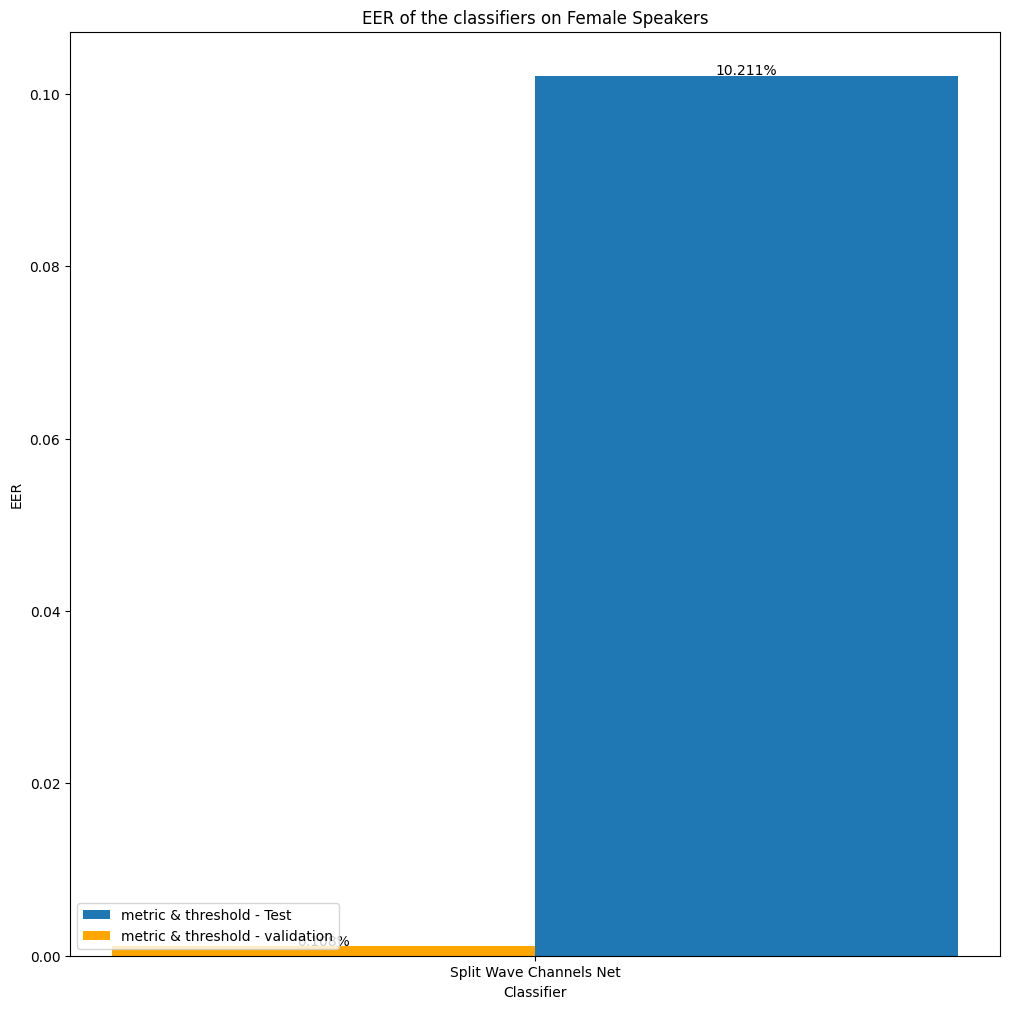

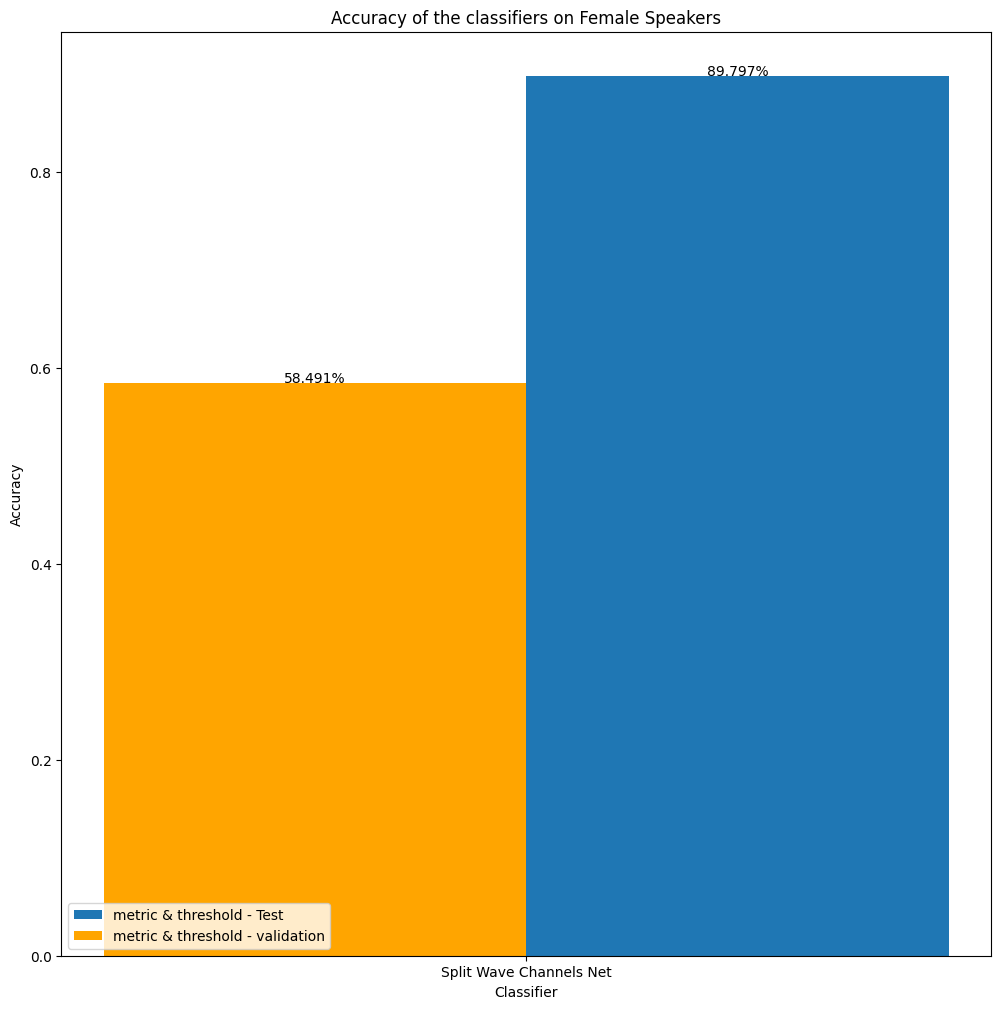

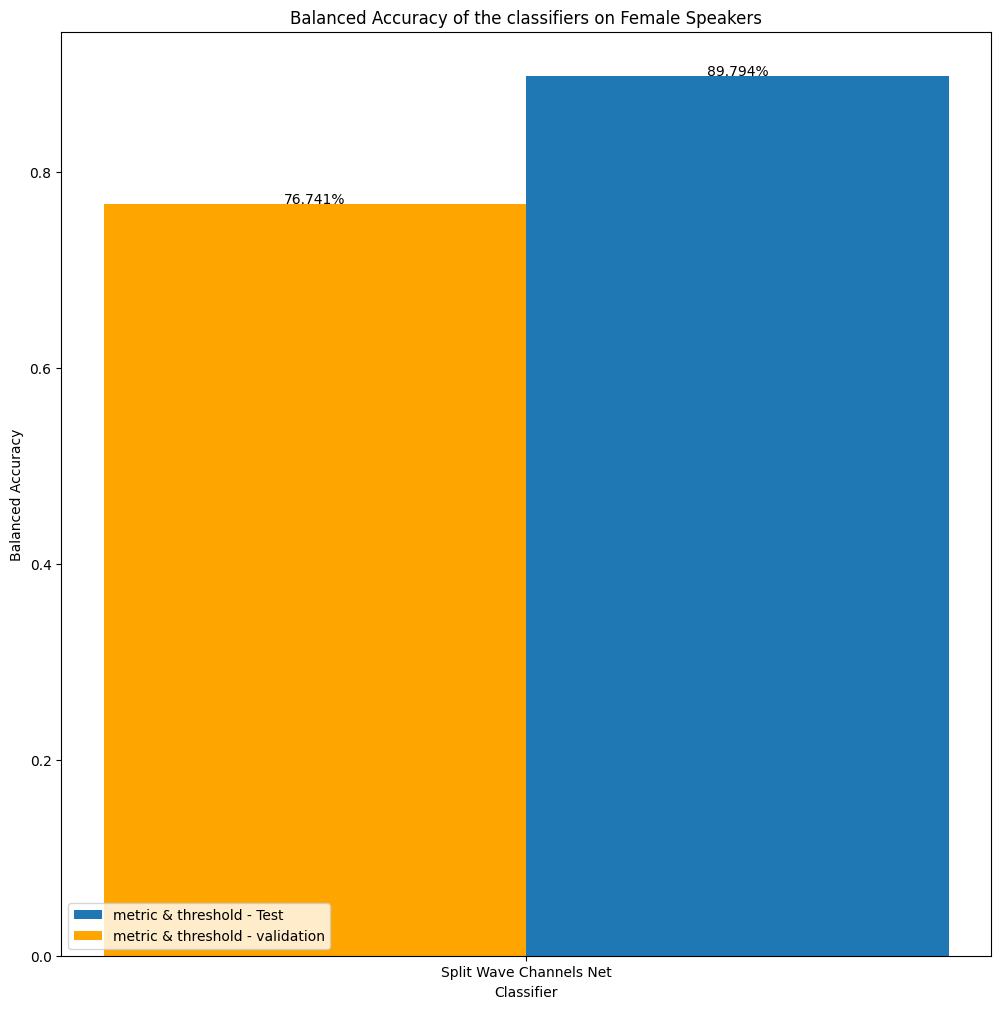

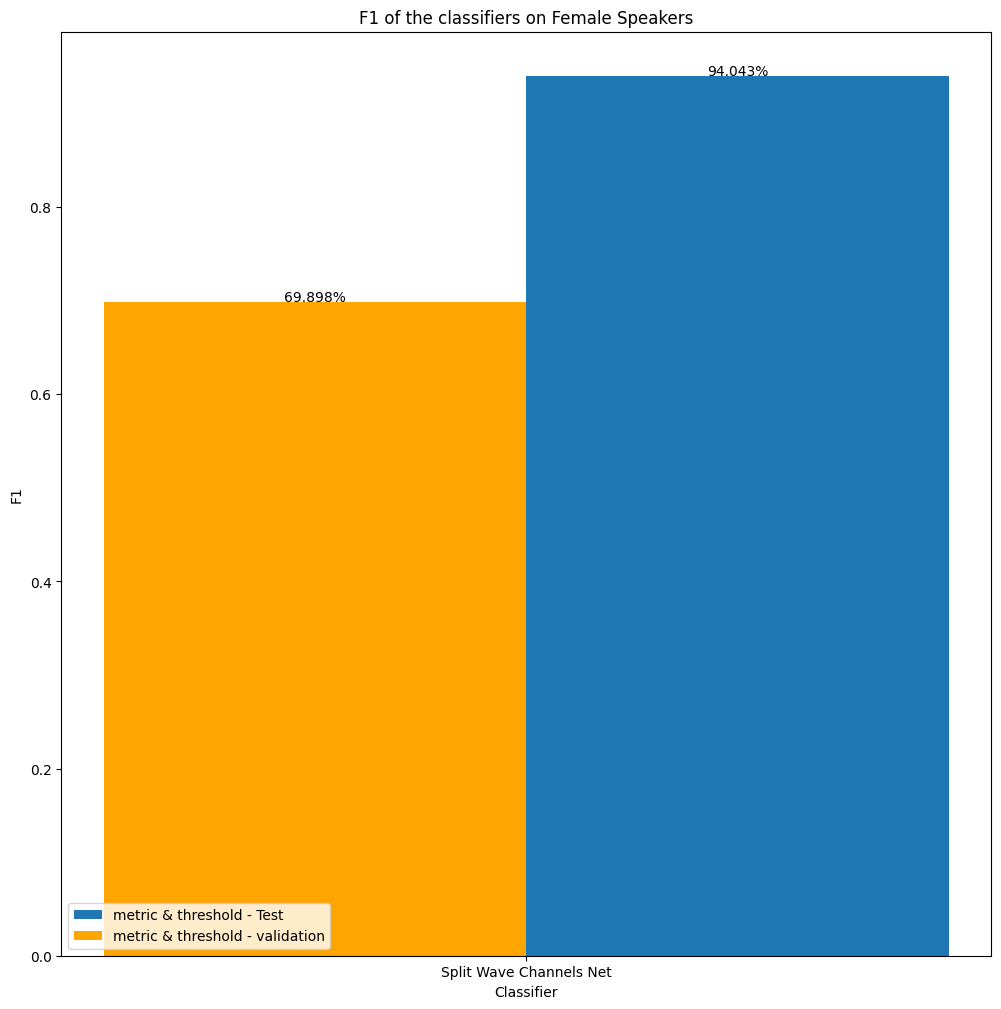

<Figure size 1200x1200 with 0 Axes>

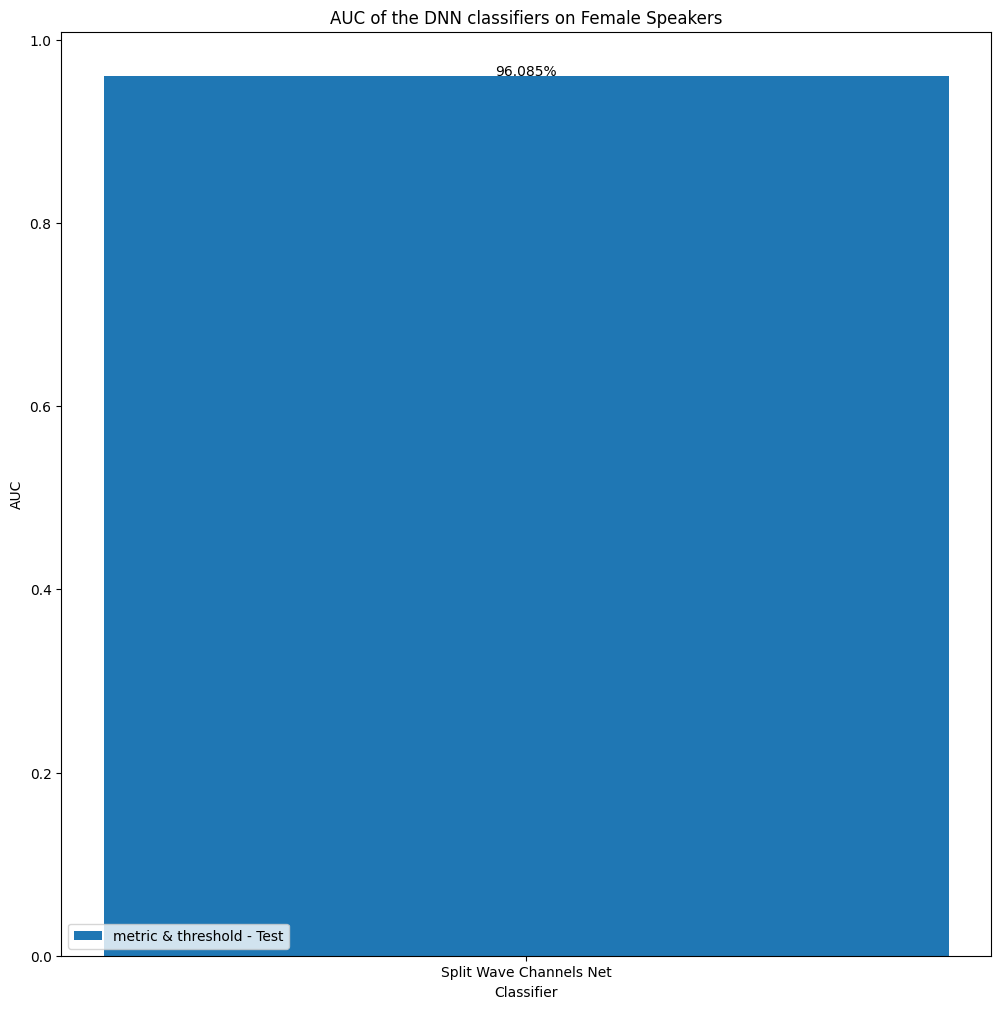

In [26]:
names = ['Split Wave Channels Net']
metric_names = ['EER','Accuracy','Balanced Accuracy','F1','AUC']
#plot hisgogram of the results: EER, Accuracy, Balanced Accuracy, AUC
metrics_list = [eer_list,acc_list,balanced_acc_list,f1_list,auc_list]
validaion_metrics_list = [eer_list_on_validaion,acc_list_with_valid_thr,balanced_acc_list_with_valid_thr,f1_list_with_valid_thr]

diff_for_bar = 0.0001
X_axis = np.arange(len(names))

#Plot the results   
for i in range(0,len(validaion_metrics_list)):
    plt.figure(figsize=(12,12))
    plt.bar(X_axis+0.2, metrics_list[i],width=0.4,label = 'metric & threshold - Test')
    plt.bar(X_axis-0.2, validaion_metrics_list[i],width=0.4,label = 'metric & threshold - validation',color='orange')
    plt.ylabel(metric_names[i])
    plt.xlabel('Classifier')
    plt.title(f"{metric_names[i]} of the classifiers on Female Speakers")
    plt.legend(loc = 'lower left')
    plt.xticks(X_axis, names)
    for j, v in enumerate(metrics_list[i]):
        plt.text(j+0.2, v+diff_for_bar, '{:.3f}%'.format(v*100), ha='center')
    for j, v in enumerate(validaion_metrics_list[i]):
        plt.text(j-0.2, v+diff_for_bar, '{:.3f}%'.format(v*100), ha='center')
    plt.show()
    
plt.figure(figsize=(12,12))
i = len(validaion_metrics_list)   
#plot hisgogram of the results: AUC
plt.figure(figsize=(12,12))
plt.bar(X_axis, metrics_list[i],width=0.4,label = 'metric & threshold - Test')
plt.ylabel(metric_names[i])
plt.xlabel('Classifier')
plt.title(f"{metric_names[i]} of the DNN classifiers on Female Speakers")
plt.legend(loc = 'lower left')
plt.xticks(X_axis, names)
for j, v in enumerate(metrics_list[i]):
        plt.text(j, v+diff_for_bar, '{:.3f}%'.format(v*100), ha='center')   
plt.show()


In [27]:
'''
import pickle

filename = 'male_and_female_model_11_29.pkl'
pickle.dump(model, open(filename, 'wb'))
'''

"\nimport pickle\n\nfilename = 'male_and_female_model_11_29.pkl'\npickle.dump(model, open(filename, 'wb'))\n"